# 02.2 TF-IDF Investigation 1

### 2.2.1 Problem Definition

The following visualization is the starting point of our investigation, showing that a true headline is returning false at a reasonable confidence of around 0.65 or so.

The issue is that words leading it to believe something is false includes "Trump", "Putin", and other words like this. We believe that the input data may be skewed resulting in proper nouns having a significant magnitude when they shouldn't. We intend to investigate this and determine how best to improve the accuracy of the TF-IDF model.

### 2.2.2 Problem Visualization

In [1]:
model_path = "../../models/tfidf_model.pkl"
vectorizer_path = "../../models/tfidf_vectorizer.pkl"


sentences = [
    "Lavrov said that the location and timing of the next Trump-Putin summit — which Trump announced after a phone call with Putin on October 16 — mattered less than implementing what the two sides agreed to in Alaska"
]


Sentence: Lavrov said that the location and timing of the next Trump-Putin summit — which Trump announced after a phone call with Putin on October 16 — mattered less than implementing what the two sides agreed to in Alaska
→ Prediction: Fake (True probability: 0.3471)


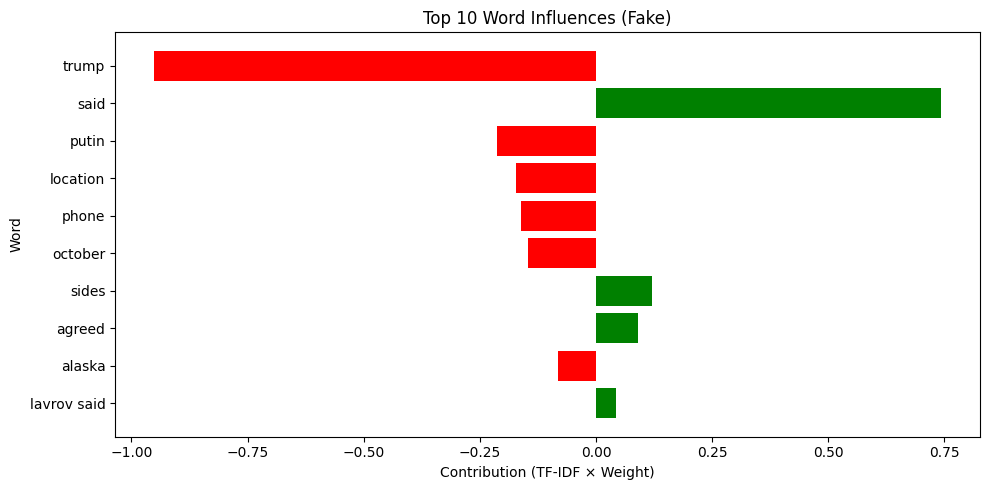

,sentence,prediction,top_positive,top_negative
0,Lavrov said that the location and timing of th...,Fake,"said, sides, agreed","trump, putin, location"


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import pickle

model = pickle.load(open(model_path, "rb"))
vectorizer = pickle.load(open(vectorizer_path, "rb"))

def explain_sentence_influence_visual(model, vectorizer, sentence, top_n=15):
    """
    Show a detailed, visual breakdown of how each word influenced the model's decision.
    """
    # === Transform sentence into TF-IDF vector ===
    X = vectorizer.transform([sentence])
    feature_names = np.array(vectorizer.get_feature_names_out())
    coefs = model.coef_.flatten()
    vec = X.toarray().flatten()

    # === Get nonzero word indices ===
    indices = np.nonzero(vec)[0]
    words = feature_names[indices]
    tfidf_values = vec[indices]
    weights = coefs[indices]
    contributions = tfidf_values * weights

    # === Build dataframe ===
    df = pd.DataFrame({
        "word": words,
        "tfidf_value": tfidf_values,
        "model_weight": weights,
        "contribution": contributions
    })
    df["direction"] = np.where(df["contribution"] > 0, "True", "Fake")
    df["abs_contribution"] = np.abs(df["contribution"])
    df = df.sort_values("abs_contribution", ascending=False)

    # === Model output ===
    total_logit = contributions.sum() + model.intercept_[0]
    probability_true = 1 / (1 + np.exp(-total_logit))
    prediction = "True" if probability_true >= 0.5 else "Fake"

    # === Print summary ===
    print(f"\nSentence: {sentence}")
    print(f"→ Prediction: {prediction} (True probability: {probability_true:.4f})")

    # === Visualization 1: Bar chart ===
    plt.figure(figsize=(10, 5))
    colors = df["direction"].map({"True": "green", "Fake": "red"})
    plt.barh(df["word"].head(top_n), df["contribution"].head(top_n), color=colors.head(top_n))
    plt.xlabel("Contribution (TF-IDF × Weight)")
    plt.ylabel("Word")
    plt.title(f"Top {top_n} Word Influences ({prediction})")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    # === Visualization 2: Highlighted sentence ===
    # Build inline-colored HTML version of the sentence
    highlighted = []
    sentence_words = sentence.split()
    word_scores = dict(zip(df["word"], df["contribution"]))

    for w in sentence_words:
        base = w.lower().strip(".,!?")
        if base in word_scores:
            score = word_scores[base]
            color = "rgba(0, 200, 0, 0.4)" if score > 0 else "rgba(255, 0, 0, 0.4)"
            highlighted.append(f"<span style='background-color:{color}'>{w}</span>")
        else:
            highlighted.append(w)

    html_sentence = " ".join(highlighted)
    display(HTML(f"<p style='font-size:1.2em'>{html_sentence}</p>"))

    return df


results = []

for s in sentences:
    df_influence = explain_sentence_influence_visual(model, vectorizer, s, top_n=10)
    results.append({
        "sentence": s,
        "prediction": "True" if df_influence["contribution"].sum() + model.intercept_[0] >= 0 else "Fake",
        "top_positive": ", ".join(df_influence[df_influence["direction"] == "True"]["word"].head(3)),
        "top_negative": ", ".join(df_influence[df_influence["direction"] == "Fake"]["word"].head(3))
    })

comparison_df = pd.DataFrame(results)
display(comparison_df)
